# Tutorial 03 — Sigma-Point Sets for the UPKF

The **Unscented Pairwise Kalman Filter (UPKF)** avoids Jacobian computation by propagating a deterministic set of **sigma points** through the nonlinear functions. The choice of sigma-point set controls:
- the **number of function evaluations** per step
- the **order of accuracy** of the mean/covariance approximation
- the **calibration** (NEES) of the resulting filter

Four sets are available in `awesomepkf`:

| Key | Reference | # Points (dim=2) | Order |
|-----|-----------|:-----------------:|-------|
| `wan2000`   | Wan & van der Merwe (2000) | $2n+1 = 5$ | 3rd |
| `cpkf`      | Arasaratnam & Haykin (2009) | $2n = 4$ | 3rd |
| `lerner2002`| Lerner (2002) | $2n^2+1 = 9$ | 5th |
| `ito2000`   | Ito & Xiong (2000) | $p^n = 9$ | 5th (GH order 3) |

**What you will learn:**
- Inspect sigma-point positions and weights geometrically
- Understand how each set trades accuracy for computation
- Compare UPKF estimation quality (MSE, NEES) across sets and models
- Benchmark computation time

**Prerequisites:** Tutorial 02 — Nonlinear Models

## Setup

In [15]:
import sys, os, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from prg import (
    NonLinear_UPKF,
    ParamNonLinear,
    ModelFactoryNonLinear,
    __version__,
)
from prg.classes.sigma_points_set import SigmaPointsSet

print(f"awesomepkf version: {__version__}")
print(f"Registered sigma-point sets: {sorted(SigmaPointsSet.registry.keys())}")

SEED        = 42
N           = 500
SIGMA_SETS  = ["wan2000", "cpkf", "lerner2002", "ito2000"]
COLORS      = ["C0", "C1", "C2", "C4"]

def make_param(model):
    p  = model.get_params().copy()
    dx = p.pop("dim_x")
    dy = p.pop("dim_y")
    return ParamNonLinear(0, dx, dy, **p)

def extract(results):
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])
    return xt, xu

def mse(xt, xu):  return float(np.mean((xt - xu) ** 2))

awesomepkf version: 0.1.0
Registered sigma-point sets: ['cpkf', 'ito2000', 'lerner2002', 'wan2000']


---
## 1. Sigma-Point Properties

### 1a. Number of sigma points vs state dimension

In [16]:
dims = [1, 2, 3, 4]

print(f"{'dim':>4}  {'wan2000':>8}  {'cpkf':>8}  {'lerner2002':>12}  {'ito2000':>9}")
print("-" * 52)
for d in dims:
    n_wan    = 2 * d + 1
    n_cpkf   = 2 * d
    n_lerner = 2 * d**2 + 1
    n_ito    = 3**d
    print(f"{d:>4}  {n_wan:>8}  {n_cpkf:>8}  {n_lerner:>12}  {n_ito:>9}")

 dim   wan2000      cpkf    lerner2002    ito2000
----------------------------------------------------
   1         3         2             3          3
   2         5         4             9          9
   3         7         6            19         27
   4         9         8            33         81


For `dim=2`: `wan2000` and `cpkf` use only 5 / 4 points (lightweight), while `lerner2002` and `ito2000` use 9 points for higher-order accuracy. For `dim=4`, `ito2000` already requires 81 points — its cost grows as $3^n$.

### 1b. Geometric visualisation — sigma points around a 2D Gaussian

We build each sigma-point set manually from a 2D mean and covariance, then plot the points with marker size proportional to the mean weight $W_m^{(i)}$.

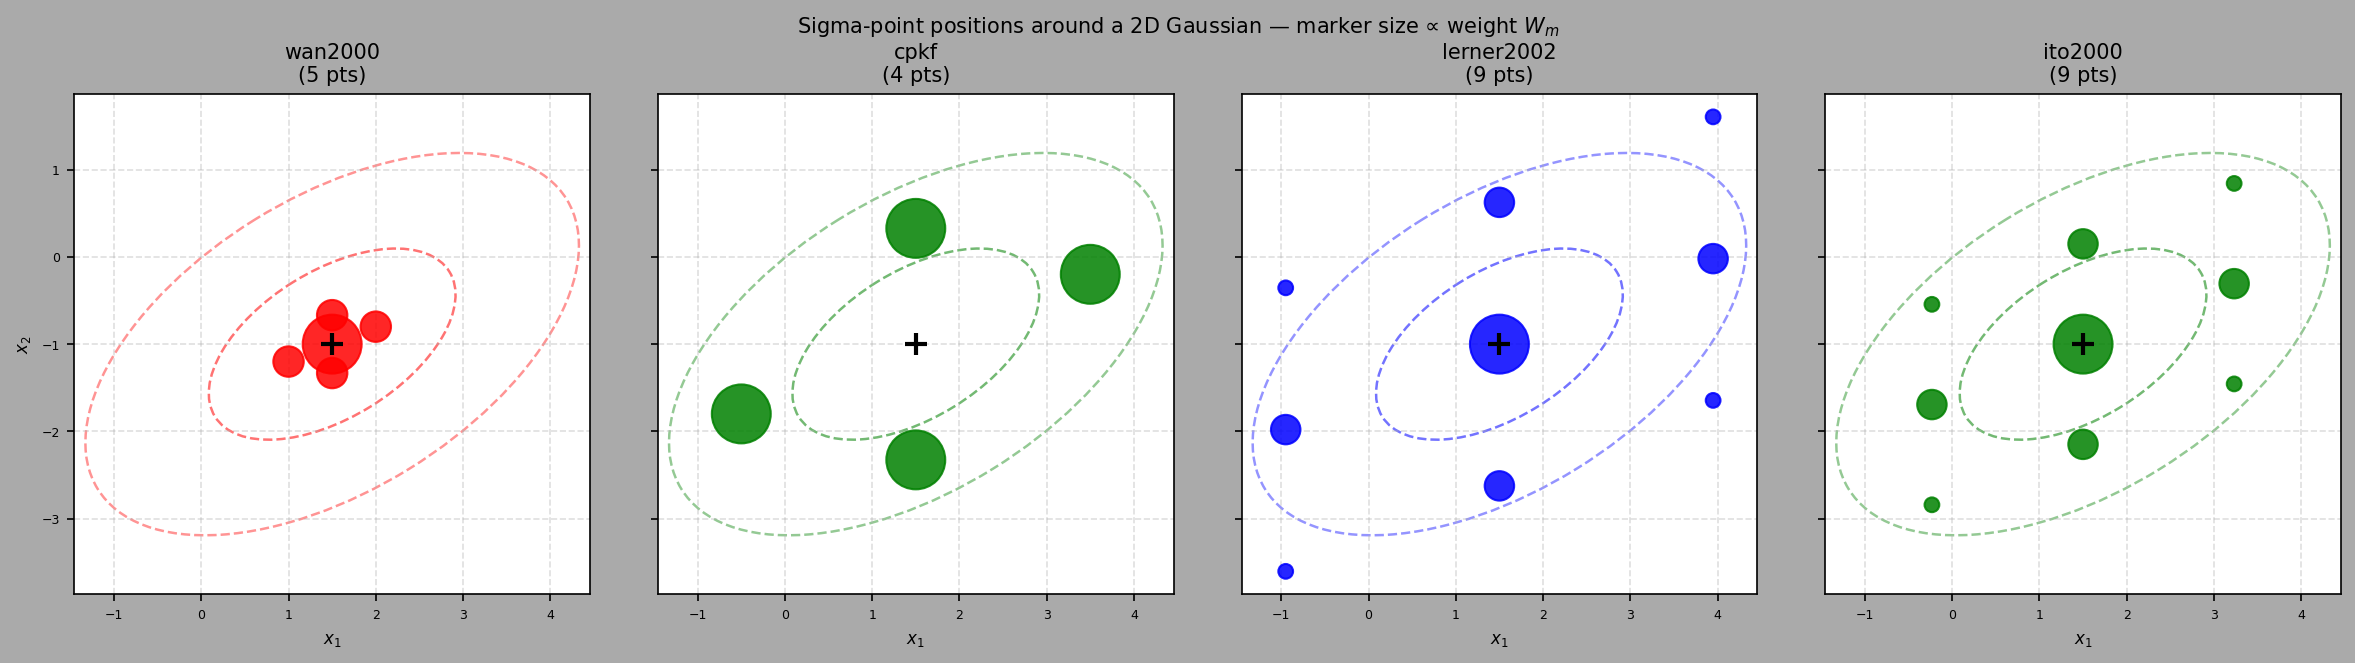

In [17]:
# Build a sample ParamNonLinear to access alpha/beta/lambda_
model_demo = ModelFactoryNonLinear.create("model_x2_y1_classic")
param_demo = make_param(model_demo)

dim  = 2
mu   = np.array([[1.5], [-1.0]])          # mean
P    = np.array([[2.0, 0.8], [0.8, 1.2]]) # covariance

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, ss, color in zip(axes, SIGMA_SETS, COLORS):
    cls    = SigmaPointsSet.registry[ss]
    sp_set = cls(dim, param_demo)
    pts    = sp_set._sigma_point(mu, P)     # (n_pts, dim, 1)
    pts    = pts[:, :, 0]                   # (n_pts, dim)
    wm     = sp_set.Wm

    # Draw 1-sigma and 2-sigma ellipses
    from matplotlib.patches import Ellipse
    vals, vecs = np.linalg.eigh(P)
    angle = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
    for nsig, alpha_ell in [(1, 0.25), (2, 0.12)]:
        w_ell = 2 * nsig * np.sqrt(vals[1])
        h_ell = 2 * nsig * np.sqrt(vals[0])
        ell = Ellipse(xy=mu.flatten(), width=w_ell, height=h_ell, angle=angle,
                      edgecolor=color, facecolor="none", lw=1.2, alpha=alpha_ell + 0.3,
                      linestyle="--")
        ax.add_patch(ell)

    # Marker size proportional to |Wm|
    sizes = 800 * np.abs(wm) / np.abs(wm).max()
    ax.scatter(pts[:, 0], pts[:, 1], s=sizes, c=color, alpha=0.85, zorder=3)
    ax.scatter(*mu.flatten(), marker="+", s=120, c="black", linewidths=2, zorder=4,
               label="mean $\\mu$")

    ax.set_title(f"{ss}\n({sp_set.nbSigmaPoint} pts)", fontsize=10)
    ax.set_xlabel("$x_1$"); ax.grid(True, ls="--", alpha=0.4)
    ax.set_aspect("equal")

axes[0].set_ylabel("$x_2$")
fig.suptitle("Sigma-point positions around a 2D Gaussian — marker size ∝ weight $W_m$",
             y=1.02)
plt.tight_layout()
plt.show()

### 1c. Weight distribution

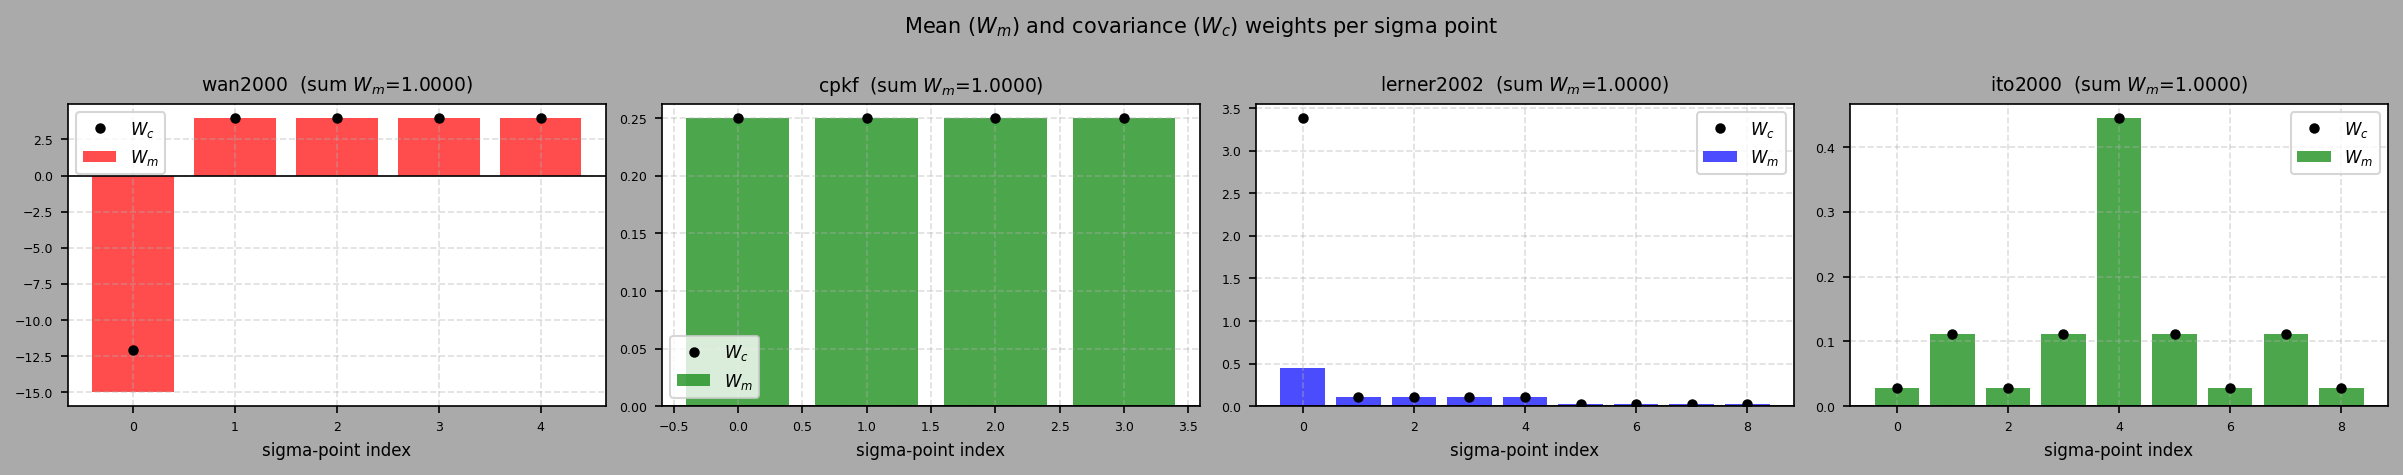

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, ss, color in zip(axes, SIGMA_SETS, COLORS):
    cls    = SigmaPointsSet.registry[ss]
    sp_set = cls(dim, param_demo)
    wm     = sp_set.Wm
    wc     = sp_set.Wc

    idx = np.arange(len(wm))
    ax.bar(idx, wm, color=color, alpha=0.7, label="$W_m$")
    ax.plot(idx, wc, "ko", ms=4, label="$W_c$")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{ss}  (sum $W_m$={wm.sum():.4f})", fontsize=9)
    ax.set_xlabel("sigma-point index"); ax.legend(fontsize=8)
    ax.grid(True, ls="--", alpha=0.4)

fig.suptitle("Mean ($W_m$) and covariance ($W_c$) weights per sigma point", y=1.02)
plt.tight_layout()
plt.show()

Note that for `wan2000` and `lerner2002`, the **central point weight $W_m^{(0)}$** can be negative for small $\alpha$, while $W_c^{(0)}$ includes a corrective term $(1 - \alpha^2 + \beta)$ that improves the covariance estimate for Gaussian distributions.

---
## 2. Estimation Accuracy: MSE Comparison

We run the UPKF with each sigma-point set on two models and compare MSE.

In [19]:
model_names = ["model_x2_y1_classic", "model_x2_y1_pairwise"]
results_all = {}   # results_all[model_name][sigma_set] = (xt, xu)

for mname in model_names:
    model = ModelFactoryNonLinear.create(mname)
    param = make_param(model)
    results_all[mname] = {}

    print(f"\nModel: {mname}")
    for ss in SIGMA_SETS:
        flt = NonLinear_UPKF(param, sigmaSet=ss, sKey=SEED)
        res = flt.process_N_data(N=N)
        xt, xu = extract(res)
        results_all[mname][ss] = (xt, xu)
        print(f"  [{ss:12s}]  MSE = {mse(xt, xu):.6f}")


Model: model_x2_y1_classic
  [wan2000     ]  MSE = 0.047110
  [cpkf        ]  MSE = 0.047079
  [lerner2002  ]  MSE = 0.047238
  [ito2000     ]  MSE = 0.045958

Model: model_x2_y1_pairwise
  [wan2000     ]  MSE = 0.115211
  [cpkf        ]  MSE = 0.115411
  [lerner2002  ]  MSE = 0.115197
  [ito2000     ]  MSE = 0.109635


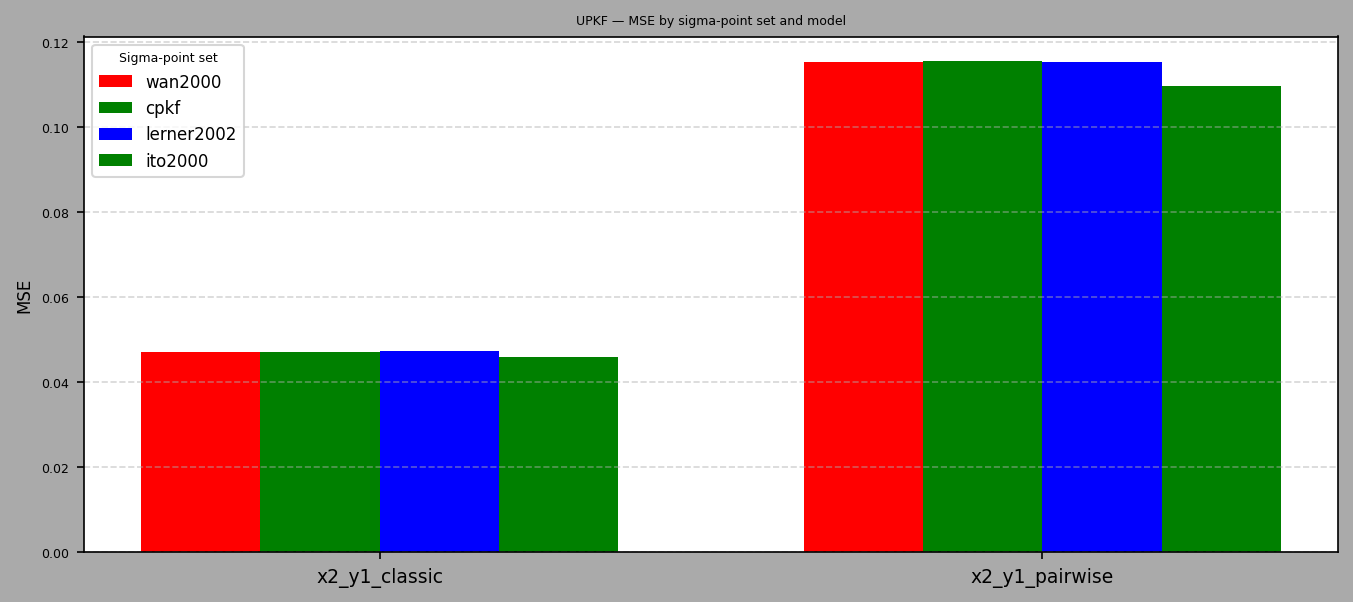

In [20]:
# Grouped bar chart: MSE per (model, sigma-set)
n_models = len(model_names)
n_sets   = len(SIGMA_SETS)
x        = np.arange(n_models)
w        = 0.18

fig, ax = plt.subplots(figsize=(9, 4))
for k, (ss, c) in enumerate(zip(SIGMA_SETS, COLORS)):
    vals = [mse(*results_all[mn][ss]) for mn in model_names]
    ax.bar(x + (k - 1.5) * w, vals, w, label=ss, color=c)

ax.set_xticks(x)
ax.set_xticklabels([mn.replace("model_", "") for mn in model_names], fontsize=9)
ax.set_ylabel("MSE")
ax.set_title("UPKF — MSE by sigma-point set and model")
ax.legend(title="Sigma-point set", fontsize=8)
ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 3. Calibration: NEES Comparison

The **Normalized Estimation Error Squared (NEES)** measures whether the filter's uncertainty estimate is consistent with the actual errors:
$$
\text{NEES}_k = \tilde{x}_k^\top P_k^{-1} \tilde{x}_k, \qquad \tilde{x}_k = x_k - \hat{x}_k
$$
A well-calibrated filter has $\overline{\text{NEES}} \approx d_x$.

In [21]:
mname_nees = "model_x2_y1_classic"
model_n    = ModelFactoryNonLinear.create(mname_nees)
param_n    = make_param(model_n)
dim_x_n    = model_n.get_params()["dim_x"]

nees_results = {}

for ss in SIGMA_SETS:
    flt = NonLinear_UPKF(param_n, sigmaSet=ss, sKey=SEED)
    res = flt.process_N_data(N=N)
    xt, xu = extract(res)
    M  = len(xu)

    # Extract update covariances from history
    df     = flt.history.as_dataframe()
    P_list = [v for v in df["PXXkp1_update"] if v is not None]
    P_arr  = np.array(P_list[:M])

    errors = xt - xu  # (M, dim_x)
    nees_steps = np.array([
        float(errors[k] @ np.linalg.inv(P_arr[k]) @ errors[k])
        for k in range(M)
    ])
    nees_results[ss] = nees_steps
    print(f"[{ss:12s}]  mean NEES = {nees_steps.mean():.4f}  (expected ≈ {dim_x_n})")

[wan2000     ]  mean NEES = 1.5746  (expected ≈ 2)
[cpkf        ]  mean NEES = 1.5993  (expected ≈ 2)
[lerner2002  ]  mean NEES = 1.5414  (expected ≈ 2)
[ito2000     ]  mean NEES = 5.4718  (expected ≈ 2)


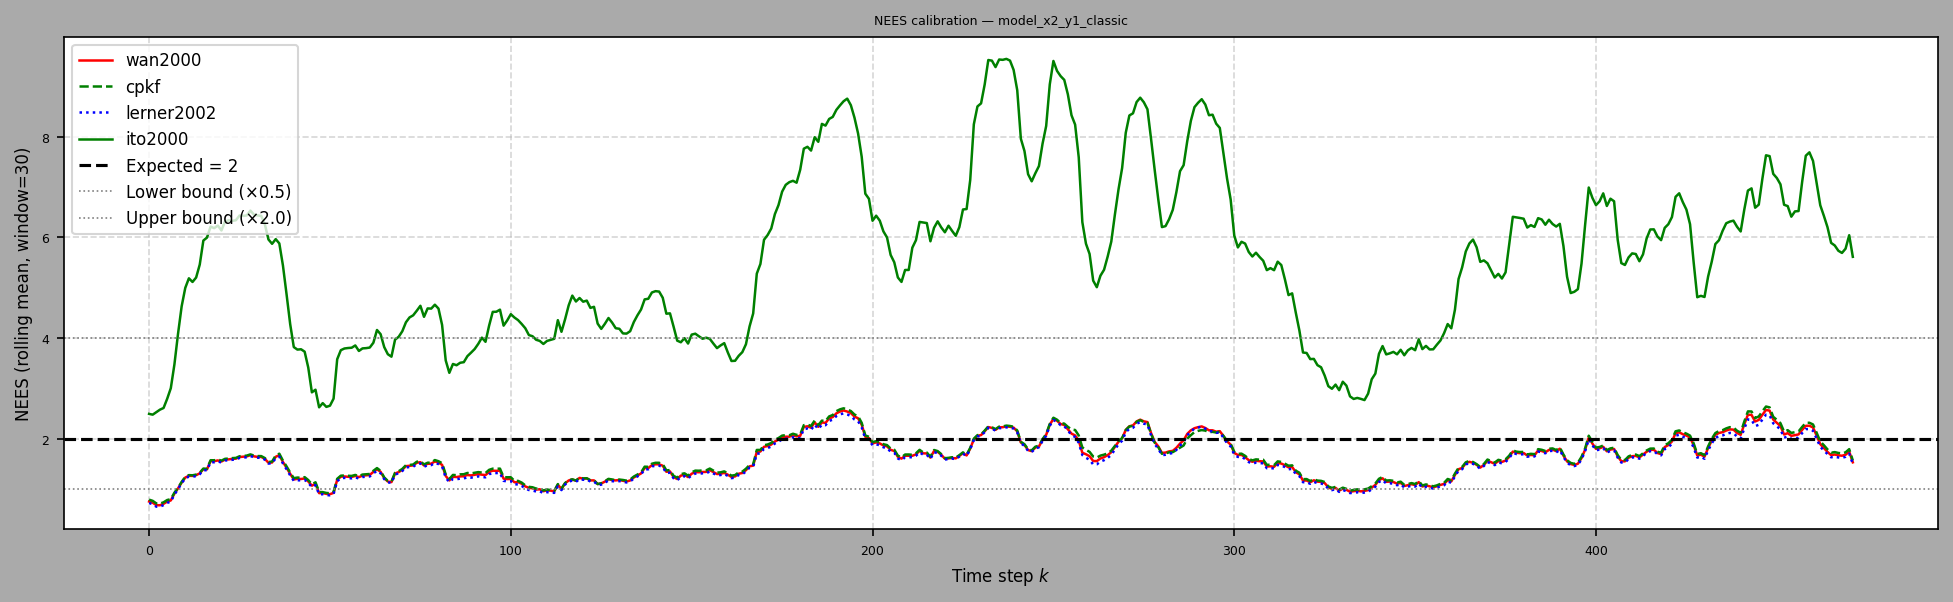

In [22]:
# Smoothed NEES over time (rolling mean, window=30)
win = 30

fig, ax = plt.subplots(figsize=(13, 4))
for ss, c in zip(SIGMA_SETS, COLORS):
    nees = nees_results[ss]
    smoothed = np.convolve(nees, np.ones(win) / win, mode="valid")
    ax.plot(smoothed, color=c, lw=1.2, label=ss)

ax.axhline(dim_x_n,         color="black", lw=1.5, ls="--",  label=f"Expected = {dim_x_n}")
ax.axhline(0.5 * dim_x_n,   color="grey",  lw=0.8, ls=":",   label="Lower bound (×0.5)")
ax.axhline(2.0 * dim_x_n,   color="grey",  lw=0.8, ls=":",   label="Upper bound (×2.0)")
ax.set_xlabel("Time step $k$")
ax.set_ylabel(f"NEES (rolling mean, window={win})")
ax.set_title(f"NEES calibration — {mname_nees}")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

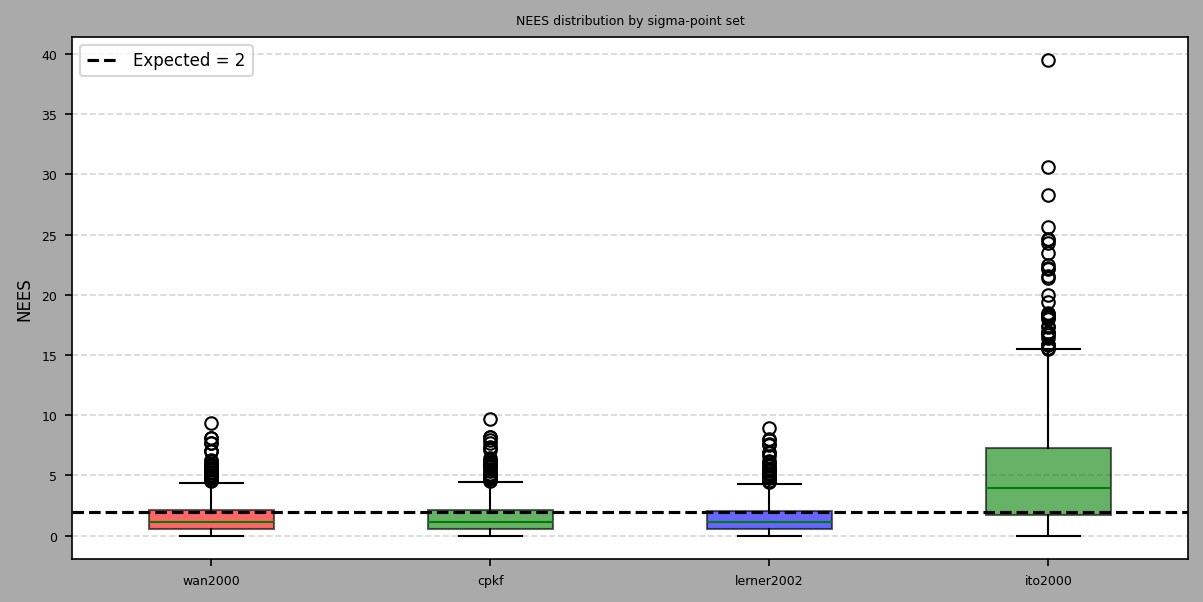

In [23]:
# Box plot of NEES distribution per sigma-point set
fig, ax = plt.subplots(figsize=(8, 4))
data    = [nees_results[ss] for ss in SIGMA_SETS]
bp      = ax.boxplot(data, tick_labels=SIGMA_SETS, patch_artist=True, notch=False)
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(dim_x_n, color="black", lw=1.5, ls="--", label=f"Expected = {dim_x_n}")
ax.set_ylabel("NEES")
ax.set_title("NEES distribution by sigma-point set")
ax.legend(fontsize=8)
ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 4. Computation Time

Each sigma-point set requires a different number of nonlinear function evaluations per step. We benchmark wall-clock time over a longer run (`N=1000`, 5 repetitions).

In [24]:
N_BENCH = 1000
N_REPS  = 3

model_b = ModelFactoryNonLinear.create("model_x2_y1_classic")
param_b = make_param(model_b)

times = {}
print(f"Benchmarking UPKF (N={N_BENCH}, {N_REPS} runs each)...")
for ss in SIGMA_SETS:
    t_runs = []
    for _ in range(N_REPS):
        flt = NonLinear_UPKF(param_b, sigmaSet=ss, sKey=SEED)
        t0  = time.perf_counter()
        flt.process_N_data(N=N_BENCH)
        t_runs.append(time.perf_counter() - t0)
    times[ss] = np.mean(t_runs)

    cls    = SigmaPointsSet.registry[ss]
    n_pts  = cls(2, param_b).nbSigmaPoint
    print(f"  [{ss:12s}]  {n_pts:2d} pts   {times[ss]*1000:.1f} ms/run")

Benchmarking UPKF (N=1000, 3 runs each)...
  [wan2000     ]   5 pts   315.7 ms/run
  [cpkf        ]   4 pts   316.3 ms/run
  [lerner2002  ]   9 pts   552.9 ms/run
  [ito2000     ]   9 pts   1583.9 ms/run


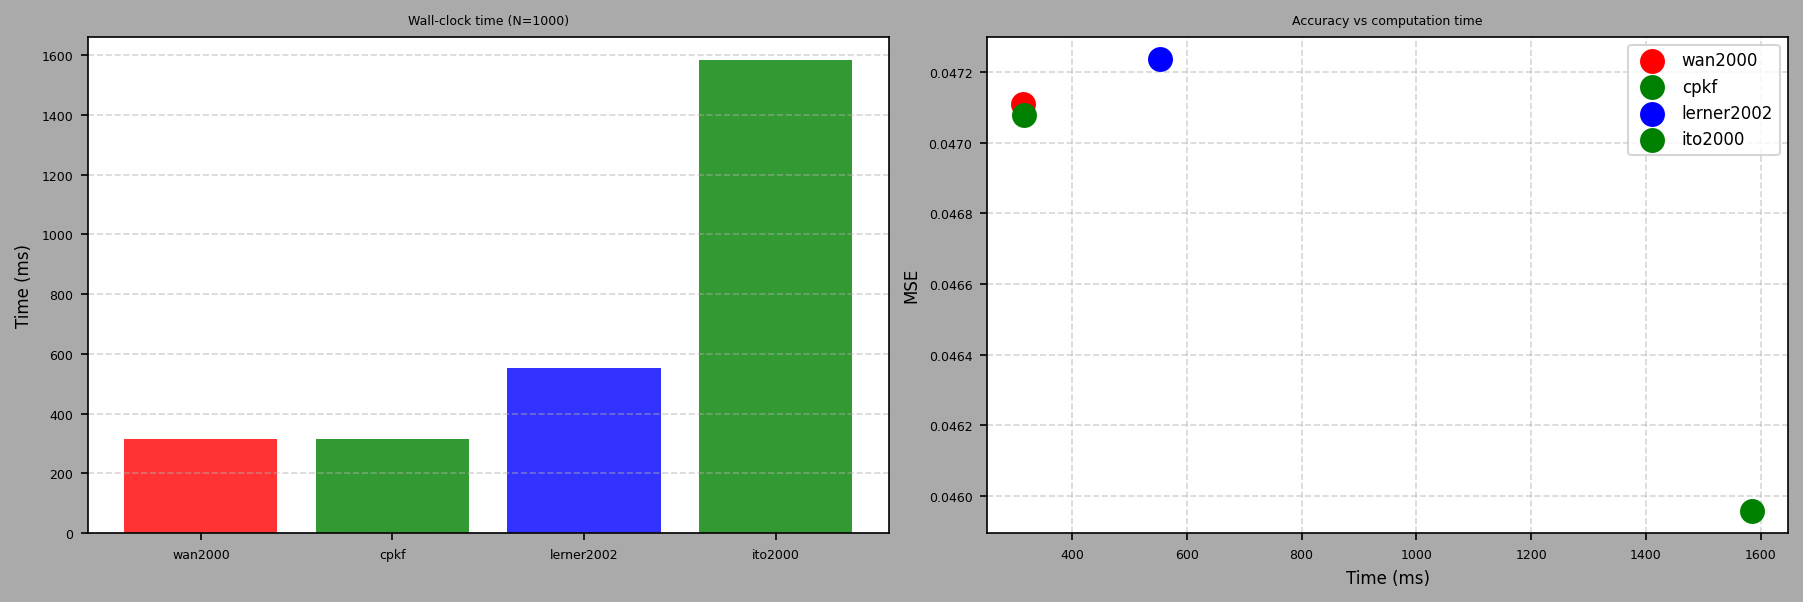

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: time bar chart
axes[0].bar(SIGMA_SETS, [times[ss] * 1000 for ss in SIGMA_SETS], color=COLORS, alpha=0.8)
axes[0].set_ylabel("Time (ms)")
axes[0].set_title(f"Wall-clock time (N={N_BENCH})")
axes[0].grid(True, axis="y", ls="--", alpha=0.5)

# Right: MSE vs time scatter
for ss, c in zip(SIGMA_SETS, COLORS):
    xt, xu = results_all["model_x2_y1_classic"][ss]
    axes[1].scatter(times[ss] * 1000, mse(xt, xu), color=c, s=120, label=ss, zorder=3)

axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("MSE")
axes[1].set_title("Accuracy vs computation time")
axes[1].legend(fontsize=8)
axes[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. Practical Recommendations

| Scenario | Recommended set | Reason |
|----------|----------------|--------|
| Default choice / low dim | `wan2000` | Proven, tunable via $\alpha$, $\beta$, $\kappa$ |
| Uniform, unbiased weights | `cpkf` | No central point, minimal point count |
| Higher-order accuracy needed | `lerner2002` | 5th-order exact, still affordable for dim ≤ 3 |
| Low dim, maximum accuracy | `ito2000` | Gauss-Hermite optimal, but $3^n$ cost for dim > 3 |

For most applications with `dim_x ≤ 3`, all four sets give comparable results. The difference becomes significant for highly nonlinear dynamics or when covariance calibration is critical.

---
## 6. Going Further

| Task | How |
|------|-----|
| Try on a higher-dim model | `ModelFactoryNonLinear.create("model_x2_y2_pairwise")` — `dim_x=4` with augmented state |
| Tune `wan2000` parameters | Modify `alpha`, `beta`, `kappa` in `ParamNonLinear` |
| Compare UPKF vs EPKF | Run `NonLinear_EPKF` on the same trajectory and overlay |
| Use CLI | `awesomepkf-upkf --nonlinear-model-name model_x2_y1_classic --sigma-set lerner2002 --N 500 --plot` |

See `tutorial_04_particle_filters.ipynb` for the PPF and PF filters.